<a href="https://colab.research.google.com/github/dharak22/Machine_Learning/blob/main/NSGA_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

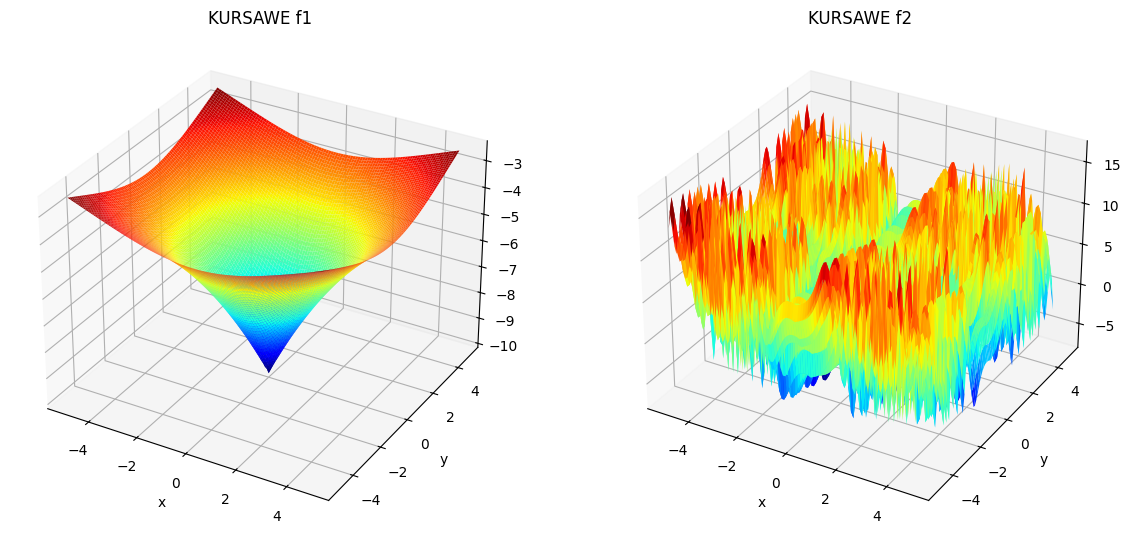

In [6]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.pyplot as plt
try :
  import numpy as np
except:
  exit()
from deap import benchmarks
X = np.arange(-5,5,0.1)
Y = np.arange(-5,5,0.1)

X,Y = np.meshgrid(X,Y)
Z1 = np.zeros(X.shape)
Z2 = np.zeros(X.shape)

for i in range(X.shape[0]):
  for j in range(X.shape[1]):
    Z1[i,j] , Z2[i,j] = benchmarks.kursawe((X[i,j],Y[i,j]))

fig = plt.figure(figsize = (12,5))

ax = fig.add_subplot(1,2,1,projection = '3d')
ax.plot_surface(X,Y,Z1,rstride = 1, cstride = 1,cmap = cm.jet, linewidth = 0.2)
plt.xlabel('x')
plt.ylabel('y')
plt.title("KURSAWE f1")

ax = fig.add_subplot(1,2,2,projection = '3d')
ax.plot_surface(X,Y,Z2,rstride = 1, cstride = 1,cmap = cm.jet, linewidth = 0.2)
plt.xlabel('x')
plt.ylabel('y')
plt.title("KURSAWE f2")

plt.subplots_adjust(left = 0, right = 1, bottom = 0, top = 1, wspace = 0 , hspace = 0)
plt.show()

In [2]:
%pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.6 MB/s eta 0:00:00


In [9]:
%pip install pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.9/295.9 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.2 MB/s eta 0:00:00


In [8]:
benchmarks.kursawe([1,1])

(-7.536383164437648, 10.414709848078965)

In [10]:
from pymoo.optimize import minimize

Problem <br>
Algorithm<br>
Stop Criteria


In [13]:
from pymoo.core.problem import Problem
import numpy as np

class ProblemWrapper(Problem):
  def _evaluate(self,designs,out,*args,**kwargs):
    res = []
    for design in designs:
      res.append(benchmarks.kursawe(design))
    out["F"] = np.array(res)



In [14]:
problem = ProblemWrapper(n_var=2,n_obj=2, xl=[-5.,-5.], xu=[5.,5.])

In [18]:
from pymoo.algorithms.moo.nsga2 import NSGA2
algorithm = NSGA2(pop_size=100)

In [19]:
stop_criteria = ('n_gen',100)

In [20]:
results = minimize(problem = problem, algorithm = algorithm , termination = stop_criteria)

In [22]:
results.F

array([[-7.21658325e+00, -7.75149611e+00],
       [-9.99958791e+00,  1.69457758e-03],
       [-9.08235622e+00,  1.29202987e-03],
       [-8.28994523e+00, -2.70379294e+00],
       [-8.89480205e+00, -3.43035166e-01],
       [-8.81914684e+00, -5.27883698e-01],
       [-8.23760812e+00, -2.96740873e+00],
       [-7.58816043e+00, -6.04883647e+00],
       [-7.37255651e+00, -7.33068576e+00],
       [-9.02683720e+00, -8.30680795e-02],
       [-8.40963713e+00, -2.13200401e+00],
       [-8.47262127e+00, -1.83328620e+00],
       [-7.40589078e+00, -7.20172535e+00],
       [-7.76066599e+00, -4.72941590e+00],
       [-7.83152018e+00, -4.23543908e+00],
       [-8.31222590e+00, -2.60998972e+00],
       [-8.33459400e+00, -2.49934656e+00],
       [-7.55642816e+00, -6.26710019e+00],
       [-8.15693557e+00, -3.33881679e+00],
       [-7.94353757e+00, -3.87481863e+00],
       [-7.56780513e+00, -6.18361777e+00],
       [-7.60138753e+00, -5.91071376e+00],
       [-7.42020513e+00, -7.12956626e+00],
       [-7.

In [24]:
res_data = results.F.T
res_data

array([[-7.21658325e+00, -9.99958791e+00, -9.08235622e+00,
        -8.28994523e+00, -8.89480205e+00, -8.81914684e+00,
        -8.23760812e+00, -7.58816043e+00, -7.37255651e+00,
        -9.02683720e+00, -8.40963713e+00, -8.47262127e+00,
        -7.40589078e+00, -7.76066599e+00, -7.83152018e+00,
        -8.31222590e+00, -8.33459400e+00, -7.55642816e+00,
        -8.15693557e+00, -7.94353757e+00, -7.56780513e+00,
        -7.60138753e+00, -7.42020513e+00, -7.85051299e+00,
        -8.11006795e+00, -7.77776550e+00, -8.73440403e+00,
        -8.70469330e+00, -7.65894457e+00, -8.06606183e+00,
        -7.53122197e+00, -8.08672518e+00, -7.67380378e+00,
        -8.92258562e+00, -7.61494133e+00, -7.26969808e+00,
        -8.18508129e+00, -7.87865781e+00, -8.13138030e+00,
        -8.03472278e+00, -8.43913545e+00, -7.68302087e+00,
        -7.81830433e+00, -8.62690310e+00, -8.01811272e+00,
        -8.74655591e+00, -8.35283795e+00, -7.31819656e+00,
        -8.43909633e+00, -7.74724862e+00, -7.35086131e+0

In [25]:
import plotly.graph_objects as go
fig = go.Figure(data = go.Scatter(x=res_data[0], y = res_data[1] , mode = 'markers'))
fig.show()